之前的章节讲解了基于值函数的方法（DQN）和基于策略的方法（REINFORCE），其中基于值函数的方法只学习一个价值函数，而基于策略的方法只学习一个策略函数。那么，一个很自然的问题是，有没有什么方法既学习价值函数，又学习策略函数呢？答案就是 Actor-Critic。Actor-Critic 是囊括一系列算法的整体架构，目前很多高效的前沿算法都属于 Actor-Critic 算法，本章接下来将会介绍一种最简单的 Actor-Critic 算法。需要明确的是，Actor-Critic 算法本质上是基于策略的算法，因为这一系列算法的目标都是优化一个带参数的策略，只是会额外学习价值函数，从而帮助策略函数更好地学习。

Actor 要做的是与环境交互，并在 Critic 价值函数的指导下用策略梯度学习一个更好的策略。
<br>Critic 要做的是通过 Actor 与环境交互收集的数据学习一个价值函数，这个价值函数会用于判断在当前状态什么动作是好的，什么动作不是好的，进而帮助 Actor 进行策略更新。

Actor-Critic 代码实践

In [2]:
import gym
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import rl_utils

首先定义策略网络PolicyNet（与 REINFORCE 算法一样）。Actor网络

In [3]:
class PolicyNet(torch.nn.Module):
    """
        策略网络，Actor网络
    """
    def __init__(self, state_dim, hidden_dim, action_dim):
        """
            初始化
        """
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        """
            前向传播
        """
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)

定义价值网络ValueNet，其输入是某个状态，输出则是状态的价值。

In [4]:
class ValueNet(torch.nn.Module):
    """
        策略网络，Critic网络
    """
    def __init__(self, state_dim, hidden_dim):
        """
            初始化
        """
        super(ValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
            前向传播
        """
        x = F.relu(self.fc1(x))
        return self.fc2(x)

定义ActorCritic算法，主要包含采取动作（take_action()）和更新网络参数（update()）两个函数；引入基线函数（baseline function）来减小方差，也可以采用 Actor-Critic 算法估计一个动作价值函数，详细公式如下：

In [11]:
class ActorCritic:
    """
        ActorCritic算法
    """
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                 gamma, device):
        # 策略网络（Actor网络）
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        # 价值网络（Critic网络）
        self.critic = ValueNet(state_dim, hidden_dim).to(device)  

        # 优化器
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),
                                                lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),
                                                 lr=critic_lr)  
        
        self.gamma = gamma
        self.device = device

    def take_action(self, state):
        """
            根据动作概率分布随机采样
            state：当前状态
        """
        # 将当前的环境状态 state（通常是 NumPy 数组）转换成 PyTorch 的 Tensor 格式，增加一个 batch 维度（通过 [state]），并移动到计算设备上
        state = torch.tensor([state], dtype=torch.float).to(self.device)

        # 得到当前策略网络的输出值
        probs = self.actor(state)

        # 利用网络输出的概率 probs，构建一个类别分布
        action_dist = torch.distributions.Categorical(probs)

        # 根据这个类别分布进行随机采样，得出一个具体的动作。概率越大的动作，被采样到的机会就越高。
        action = action_dist.sample()

        # 将 PyTorch Tensor 格式的动作提取为普通的 Python 标量（数值）并返回，以便环境执行该动作
        return action.item()
    
    def update(self, transition_dict):
        """
            模型更新，即更新策略
            transition_dict：从经验回放池取出的一个批次（Batch）的数据字典
        """

        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

        # 时序差分目标，即优势函数中的 V 值
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)

        # 用 TD 目标减去 Critic 网络对当前状态的预测价值 V(S_t)，即得到优势函数
        td_delta = td_target - self.critic(states)  
        
        # 计算 Actor（策略）网络的损失
        log_probs = torch.log(self.actor(states).gather(1, actions))
        actor_loss = torch.mean(-log_probs * td_delta.detach())

        # 计算 Critic（价值）网络的损失：
        critic_loss = torch.mean(F.mse_loss(self.critic(states), td_target.detach()))

        # 反向传播与参数更新：
        self.actor_optimizer.zero_grad()
        self.critic_optimizer.zero_grad()
        actor_loss.backward()                   # 计算策略网络的梯度
        critic_loss.backward()                  # 计算价值网络的梯度
        self.actor_optimizer.step()             # 更新策略网络的参数
        self.critic_optimizer.step()            # 更新价值网络的参数

开始训练

In [12]:
actor_lr = 1e-3
critic_lr = 1e-2
num_episodes = 1000
hidden_dim = 128
gamma = 0.98
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'CartPole-v0'
env = gym.make(env_name)
env.seed(0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = ActorCritic(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                    gamma, device)

return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked 

Iteration 9: 100%|██████████| 100/100 [00:06<00:00, 16.23it/s, episode=1000, return=200.000]


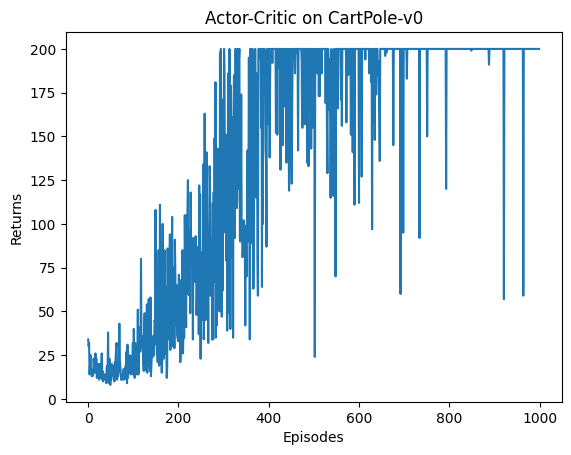

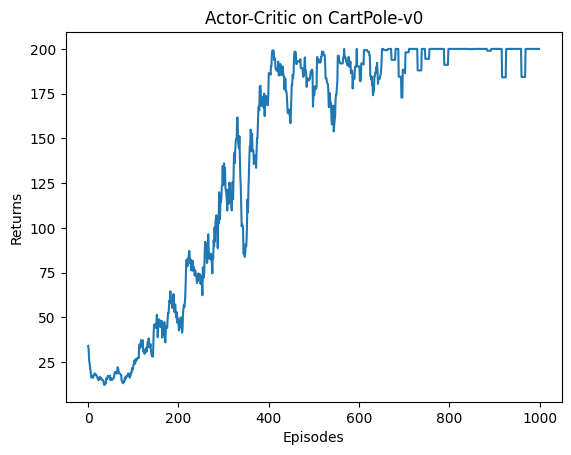

In [13]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Actor-Critic on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Actor-Critic on {}'.format(env_name))
plt.show()

Actor-Critic 算法很快便能收敛到最优策略，并且训练过程非常稳定，抖动情况相比 REINFORCE 算法有了明显的改进，这说明价值函数的引入减小了方差。